In [458]:
import pandas as pd
Dataset = pd.read_csv("50_Startups.csv")
Dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [459]:
Dataset = pd.get_dummies(Dataset,dtype = int, drop_first = True)
Dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [460]:
Dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='str')

In [461]:
Independent = Dataset[['R&D Spend', 'Administration', 'Marketing Spend', 'State_Florida', 'State_New York']]
Independent

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.95,311613.29,0,1
9,123334.88,108679.17,304981.62,0,0


In [462]:
Dependent = Dataset [[ 'Profit']]
Dependent

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94
5,156991.12
6,156122.51
7,155752.60
8,152211.77
9,149759.96


In [463]:
from sklearn.model_selection import train_test_split
X_Train, X_Test, Y_Train, Y_Test = train_test_split(Independent, Dependent, test_size = 0.3, random_state = 0)

In [464]:
X_Train

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
7,130298.13,145530.06,323876.68,1,0
14,119943.24,156547.42,256512.92,1,0
45,1000.23,124153.04,1903.93,0,1
48,542.05,51743.15,0.00,0,1
29,65605.48,153032.06,107138.38,0,1
15,114523.61,122616.84,261776.23,0,1
30,61994.48,115641.28,91131.24,1,0
32,63408.86,129219.61,46085.25,0,0
16,78013.11,121597.55,264346.06,0,0
42,23640.93,96189.63,148001.11,0,0


In [465]:
X_Test

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
28,66051.52,182645.56,118148.20,1,0
11,100671.96,91790.61,249744.55,0,0
10,101913.08,110594.11,229160.95,1,0
41,27892.92,84710.77,164470.71,1,0
2,153441.51,101145.55,407934.54,1,0
27,72107.60,127864.55,353183.81,0,1
38,20229.59,65947.93,185265.10,0,1
31,61136.38,152701.92,88218.23,0,1
22,73994.56,122782.75,303319.26,1,0
4,142107.34,91391.77,366168.42,1,0


In [466]:
Y_Train

,Profit
7,155752.60
14,132602.65
45,64926.08
48,35673.41
29,101004.64
15,129917.04
30,99937.59
32,97427.84
16,126992.93
42,71498.49


In [467]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(criterion = "squared_error", splitter = "best", max_features = None )
regressor = regressor.fit(X_Train, Y_Train)

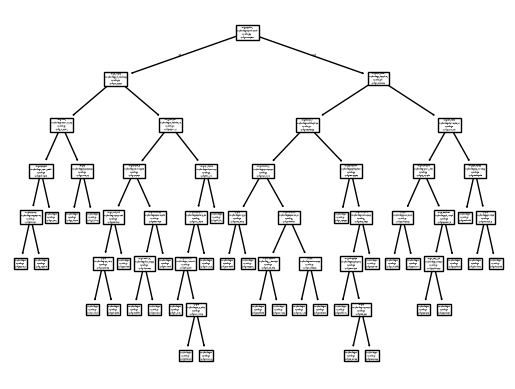

In [468]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [469]:
Y_Pred = regressor.predict(X_Test)
Y_Pred

array([ 99937.59, 141585.52, 141585.52,  78239.91, 182901.99, 111313.02,
        69758.98, 101004.64, 118474.03, 182901.99,  89949.14,  89949.14,
       122776.86,  89949.14, 125370.37])

In [470]:
from sklearn.metrics import r2_score
r_score = r2_score(Y_Test, Y_Pred)
r_score

0.9267012389029516

In [471]:
import pickle as pc
Filename = "Decision_Tree_Phase1_Model.sav"
Filename

'Decision_Tree_Phase1_Model.sav'

In [472]:
pc.dump(regressor,open(Filename,'wb'))

In [473]:
Loaded_File = pc.load(open ("Decision_Tree_Phase1_Model.sav",'rb'))
Result = Loaded_File.predict ([[22180.74, 154900.14,28400.72,1,0]])
Result

E:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([65200.33])